In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import joblib

In [2]:
df = pd.read_csv("reviews.csv")

print("Shape:", df.shape)
df.head()


Shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [3]:
# Keep only clear sentiment
df = df[df["Score"] != 3]

df["label"] = df["Score"].apply(lambda x: 1 if x >= 4 else 0)

print(df["label"].value_counts())


label
1    443777
0     82037
Name: count, dtype: int64


In [4]:
df_pos = df[df["label"] == 1]
df_neg = df[df["label"] == 0]

# Downsample majority class
df_pos_sampled = df_pos.sample(
    n=len(df_neg),
    random_state=42
)

# Combine and shuffle
df_balanced = pd.concat([df_pos_sampled, df_neg])
df_balanced = df_balanced.sample(frac=1, random_state=42)

print(df_balanced["label"].value_counts())


label
1    82037
0    82037
Name: count, dtype: int64


In [5]:
texts = df_balanced["Text"].astype(str)
labels = df_balanced["label"]

X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)


In [6]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [7]:
model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000, n_jobs=-1)

In [8]:
y_pred = model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9056
F1-score: 0.9052

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     24612
           1       0.91      0.90      0.91     24611

    accuracy                           0.91     49223
   macro avg       0.91      0.91      0.91     49223
weighted avg       0.91      0.91      0.91     49223



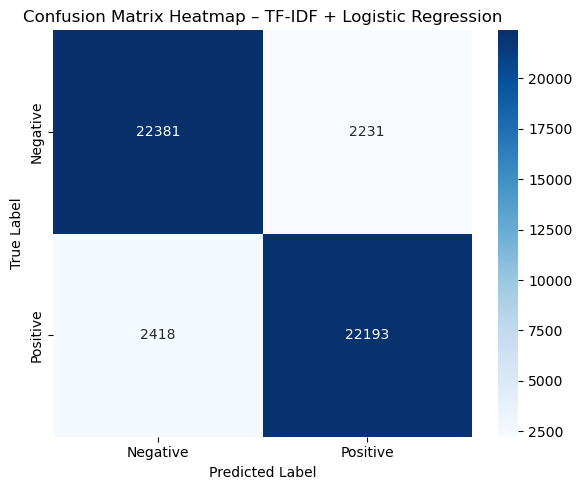

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap – TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()


In [10]:
train_pred = model.predict(X_train_tfidf)

train_acc = accuracy_score(y_train, train_pred)
train_f1 = f1_score(y_train, train_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Train F1-score: {train_f1:.4f}")


Train Accuracy: 0.9270
Train F1-score: 0.9268


In [12]:
# save artifacts
joblib.dump(tfidf, "tfidf_vectorizer.joblib")
joblib.dump(model, "text_classifier.joblib")

print("Model and vectorizer saved.")

Model and vectorizer saved.
